# Day 4 — 森を建てる（ランダムフォレスト）

**今日のゴール**
1. Day 3 で見た「木1本（深さ無制限）は過学習する」を、**森（たくさんの木の多数決）**が和らげるか、自分の目で確かめる
2. ランダムフォレストの "Random" の正体を体感する
   - **バギング**＝木ごとに違う行（データ）で学ぶ（復元抽出）
   - **特徴量のランダム選択**＝各分割で使う列を一部だけに絞る
3. 公平に比べるため、1回の抜き打ち（Day 3 の train_test_split）ではなく **「10回測って平均」（交差検証）** で勝負する

🧱 = 足場（私が用意した。今日の主役ではない）　🎯 = 本筋（あなたが書く）　✋ = 走らせる前に予想する

## 🧱 1. 道具を読み込む（import）

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
# RandomForestClassifier は本筋なので、ここでは import しない（あなたが下で書く）

print('準備OK')

準備OK


## 🧱 2. データを読み込んで X / y に分ける（前回までと同じ）

ここは Day 2・3 で通った道なので足場として渡す。今日集中するのは「森」の部分。

In [27]:
df = pd.read_csv('../../data/chat_sessions.csv')

X = df[["used_summary", "turns", "stay_minutes"]]   # 手がかり（列）
y = df["deepened"]                                    # 本当の答え

print('データ:', df.shape)
df.head()

データ: (400, 4)


,turns,used_summary,stay_minutes,deepened
0,3,1,1,1
1,23,1,18,1
2,19,0,31,0
3,13,1,55,1
4,13,0,44,0


## 🧱 3. 測り方 — 「1回の抜き打ち」より「10回測って平均」

Day 3 は `train_test_split` で **1回だけ** 抜き打ちテストした。でも1回だと、
たまたま簡単な test を引けば高得点、難しい test を引けば低得点…と **運で±数%ブレる**。

そこで今日は、データを10個に分けて「9個で学んで残り1個で採点」を**10回**やり、その平均を成績とする。
これを **交差検証（cross-validation）** と呼ぶ。`cross_val_score(モデル, X, y, cv=10)` 一発で出る。

> これは今日の本筋ではないので道具として渡す。交差検証そのものは別の回でちゃんと掘る。
> 今は「1回より公平な物差し」とだけ思っておけばOK。

## 🧱 4. 比較相手：木1本（前回あなたが書いたやつ）

森の強さを測る「ものさし」を2つ、交差検証で出しておく。
- **深さ無制限の木** ＝ 過学習の見本
- **深さ3の木** ＝ Day 3 で見つけたスイートスポット

> `cross_val_score(...)` は10回ぶんの正解率が入った配列を返す。`.mean()` が平均、`.std()` がブレ幅。
> このあと森でも**同じ呼び方**で測る。

In [28]:
# --- 木1本（深さ無制限）＝過学習の見本 ---
deep_cv = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=10)

# --- 木1本（深さ3）＝Day 3 のスイートスポット ---
shallow_cv = cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=42), X, y, cv=10)

print(f'木1本(無制限) : {deep_cv.mean():.3f} +/- {deep_cv.std():.3f}   <- 過学習')
print(f'木1本(深さ3)  : {shallow_cv.mean():.3f} +/- {shallow_cv.std():.3f}   <- Day3 の天井')

木1本(無制限) : 0.727 +/- 0.072   <- 過学習
木1本(深さ3)  : 0.797 +/- 0.041   <- Day3 の天井


## ✋ 走らせる前に「予想」する

下の森を書く前に、予想をメモして:

- **森（深さ無制限の木をたくさん多数決）** の CV 平均は、**木1本(無制限) ≒ 0.73** をどうする？ 上がる／変わらない／下がる？
- その森は、わざわざ手で深さ3に絞った **木1本(深さ3) ≒ 0.80** に**勝てる**と思う？
- 森の各木は深さ無制限（＝過学習する木）なのに、多数決にすると何が起きる？

予想をメモしてから、下を書いて答え合わせ。

## 🎯 5. ここが今日の本筋 — 森を建てて測る

下のヒントだけを頼りに、**自分で**書いてください。コピペで動く完成形は渡しません。

**やること:**
1. **import**：森は `sklearn.ensemble` にいる（決定木の `sklearn.tree` とは別の引き出し。`ensemble`＝「集団」）。クラス名は `RandomForestClassifier`。
2. **箱を作る**：使い方は `DecisionTreeClassifier` と双子。新しいツマミ `n_estimators`＝木を何本建てるか（まずは 100）。`random_state=42` も付ける。深さ（`max_depth`）は**あえて制限しない**（理由は答え合わせで）。
3. **測る**：上の「木1本」セルと**同じ呼び方**で `cross_val_score(森, X, y, cv=10)` を `forest_cv` に入れる。
4. `forest_cv.mean()` と `.std()` を print。

In [29]:
# 🎯 ここを自分で埋める（... のままだと実行時にエラーになります）

# 1. import（森は sklearn.ensemble。クラス名は RandomForestClassifier）
from sklearn.ensemble import RandomForestClassifier

# 2. 森の箱を作る（n_estimators=木の本数, random_state=42, 深さは制限しない）
forest = RandomForestClassifier(n_estimators=10, random_state=42)

# 3. 測る（上の木1本セルと同じ cross_val_score の呼び方で）
forest_cv = cross_val_score(forest, X, y, cv=10)

# 4. 結果を表示
print(f'森          : {forest_cv.mean():.3f} +/- {forest_cv.std():.3f}')

森          : 0.740 +/- 0.104


## 🧱 6. 答え合わせ — 木1本 vs 森

上の `forest_cv` まで出せたら、このセルを実行。CV 平均を並べて棒グラフにする（ヒゲ＝ブレ幅）。

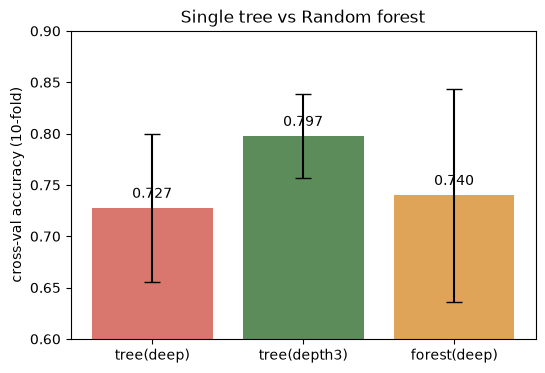

保存: notebooks/day4_forest.png


Bad pipe message: %s [b'deflate\r\nAuthorization: Bearer test-webhook']
Bad pipe message: %s [b'ecret\r\nContent-Type: application/json\r\nConte', b'-Length: 132\r\nConnection: close\r\n\r\n{"event":{"id":"evt_cancel","type":"CANCELLATION","app_user_id":"user1","e']


In [30]:
labels = ['tree(deep)', 'tree(depth3)', 'forest(deep)']
means  = [deep_cv.mean(), shallow_cv.mean(), forest_cv.mean()]
stds   = [deep_cv.std(),  shallow_cv.std(),  forest_cv.std()]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=6,
              color=['#d9776f', '#5b8c5a', '#e0a458'])
ax.set_ylim(0.6, 0.9)
ax.set_ylabel('cross-val accuracy (10-fold)')
ax.set_title('Single tree vs Random forest')
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, m + 0.01, f'{m:.3f}', ha='center')
fig.savefig('day4_forest.png', dpi=120, bbox_inches='tight')
plt.show()
print('保存: notebooks/day4_forest.png')